In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.16.1


In [2]:
corpus = """
Deep learning is one of the most exciting fields of artificial intelligence.
It enables computers to learn patterns from large amounts of data.
Machine learning algorithms improve automatically through experience.
Recurrent neural networks are useful for sequence modeling tasks.
They process sequential information one step at a time.
Long Short Term Memory networks solve the vanishing gradient problem.
LSTM models remember important information over long sequences.
GRU is a simplified version of LSTM with fewer parameters.
Text generation models learn grammar and contextual relationships.
Natural language processing allows machines to understand human language.
Deep learning models are widely used in chatbots, translation systems,
speech recognition, recommendation systems and text generation.
Artificial intelligence is transforming healthcare, education, finance,
transportation and many other industries.
"""
print(corpus)


Deep learning is one of the most exciting fields of artificial intelligence.
It enables computers to learn patterns from large amounts of data.
Machine learning algorithms improve automatically through experience.
Recurrent neural networks are useful for sequence modeling tasks.
They process sequential information one step at a time.
Long Short Term Memory networks solve the vanishing gradient problem.
LSTM models remember important information over long sequences.
GRU is a simplified version of LSTM with fewer parameters.
Text generation models learn grammar and contextual relationships.
Natural language processing allows machines to understand human language.
Deep learning models are widely used in chatbots, translation systems,
speech recognition, recommendation systems and text generation.
Artificial intelligence is transforming healthcare, education, finance,
transportation and many other industries.



In [3]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

input_sequences = []

for line in corpus.split('\n'):
    
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input Shape :", X.shape)
print("Output Shape:", y.shape)

Vocabulary Size: 95
Input Shape : (108, 11)
Output Shape: (108,)


In [4]:
rnn_model = Sequential([
    
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(total_words, activation="softmax")
])

rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("Vanilla RNN Training Completed")

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-07-20 18:34:51.911037: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-07-20 18:34:51.911066: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-20 18:34:51.911086: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-07-20 18:34:51.911258: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-20 18:34:51.911320: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-0

Vanilla RNN Training Completed


In [5]:
lstm_model = Sequential([
    
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(total_words, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("LSTM Training Completed")

LSTM Training Completed


In [6]:
gru_model = Sequential([
    
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(total_words, activation="softmax")
])

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("GRU Training Completed")

GRU Training Completed


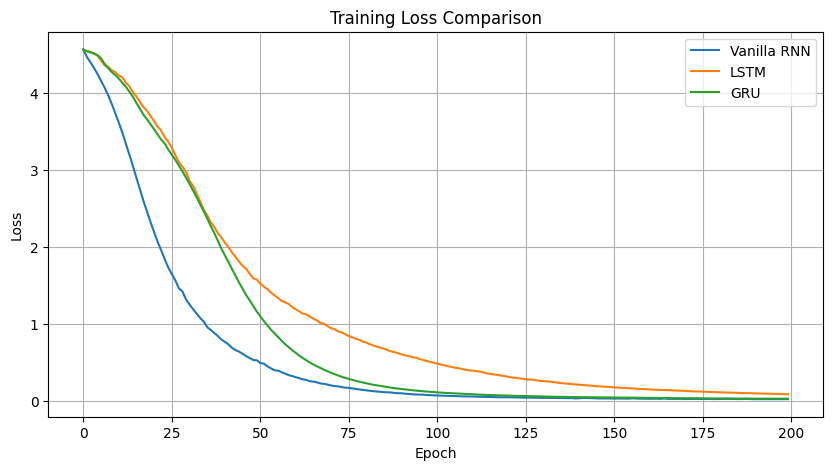

In [7]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['loss'], label="Vanilla RNN")

plt.plot(lstm_history.history['loss'], label="LSTM")

plt.plot(gru_history.history['loss'], label="GRU")

plt.title("Training Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [8]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding="pre"
        )

        prediction = model.predict(token_list, verbose=0)

        predicted_index = np.argmax(prediction)

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [9]:
print("----------- Generated Text -----------\n")

print("Vanilla RNN")
print(generate_text(rnn_model,
                    "deep learning",
                    next_words=10))

print()

print("LSTM")
print(generate_text(lstm_model,
                    "deep learning",
                    next_words=10))

print()

print("GRU")
print(generate_text(gru_model,
                    "deep learning",
                    next_words=10))

----------- Generated Text -----------

Vanilla RNN
deep learning models are widely used in chatbots translation systems learn text

LSTM
deep learning is one of the most exciting fields of artificial intelligence

GRU
deep learning models are widely used in chatbots translation systems systems and


In [10]:
print("Final Training Accuracy\n")

print("Vanilla RNN :", round(rnn_history.history['accuracy'][-1]*100,2), "%")

print("LSTM        :", round(lstm_history.history['accuracy'][-1]*100,2), "%")

print("GRU         :", round(gru_history.history['accuracy'][-1]*100,2), "%")

Final Training Accuracy

Vanilla RNN : 98.15 %
LSTM        : 98.15 %
GRU         : 99.07 %
